imports and read

In [2]:
import pandas as pd
import numpy as np
df = pd.read_csv('.././data/development.csv', index_col=0, header=0).drop(columns='path')

Missing values

In [3]:
df.isna().sum()

sampling_rate             0
age                       0
gender                    0
ethnicity                 0
mean_pitch                0
max_pitch                 0
min_pitch                 0
jitter                    0
shimmer                   0
energy                    0
zcr_mean                  0
spectral_centroid_mean    0
tempo                     0
hnr                       0
num_words                 0
num_characters            0
num_pauses                0
silence_duration          0
dtype: int64

unique values in each column

In [4]:
for col in df.columns:
    print(col, '\t', np.unique(df[col]))

sampling_rate 	 [22050]
age 	 [ 6.   7.  15.  15.5 16.  17.  18.  19.  20.  21.  22.  22.5 23.  24.
 25.  26.  27.  27.5 28.  29.  30.  31.  32.  33.  34.  35.  36.  37.
 38.  39.  40.  41.  42.  43.  44.  45.  46.  47.  48.  49.  50.  51.
 52.  53.  54.  55.  56.  57.  58.  59.  60.  61.  62.  63.  64.  65.
 66.  67.  68.  69.  70.  71.  72.  73.  74.  75.  76.  77.  78.  79.
 80.  81.  82.  83.  84.  85.  86.  88.  90.  97. ]
gender 	 ['female' 'male']
ethnicity 	 ['afemai' 'agni' 'akan' 'albanian' 'amazigh' 'amharic' 'annang' 'arabic'
 'armenian' 'ashanti' 'azerbaijani' 'bafang' 'baga' 'bai' 'bambara'
 'bamun' 'bari' 'basque' 'bavarian' 'belarusan' 'bengali' 'bosnian'
 'bulgarian' 'burmese' 'cameroonian' 'cantonese' 'carolinian' 'catalan'
 'cebuano' 'chaldean' 'chamorro' 'chichewa' 'chittagonian' 'congolese'
 'croatian' 'czech' 'danish' 'dari' 'dinka' 'dutch' 'ebira' 'edo'
 'english' 'estonian' 'ewe' 'fang' 'fanti' 'faroese' 'farsi' 'fataluku'
 'fijian' 'filipino' 'finnish' 'french'

female and males are balanced

In [5]:
df['gender'].value_counts()

gender
female    1468
male      1465
Name: count, dtype: int64

age is not balanced and is not well distributed, being a chi-square distribution

<Axes: ylabel='Frequency'>

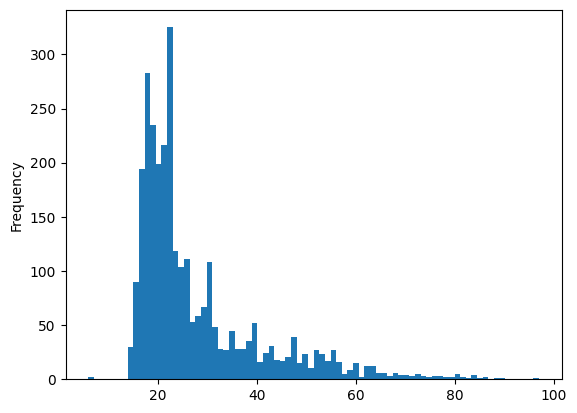

In [6]:
df['age'].map(lambda x:round(x)).plot(kind='hist', bins=80) if 1 else df['age'].map(round).plot(kind='box')

In [7]:
df[df['age'] >df['age'].mean()+0.5*df['age'].std()].shape

(637, 18)

In [8]:
df['age'].mean()+0.5*df['age'].std()

np.float64(34.44454392864352)

num words has outliers and is not well distributed

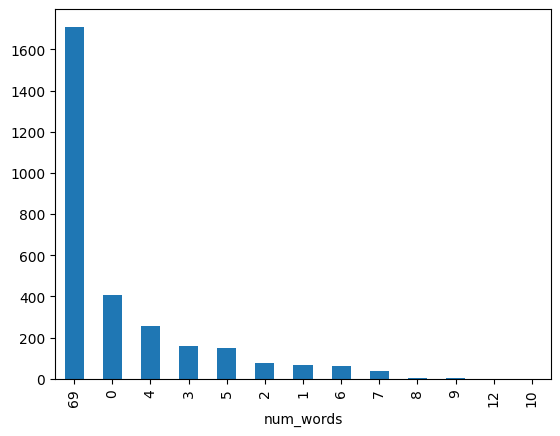

In [9]:
df['num_words'].value_counts().plot.bar();

num characters has outliers and is not well distributed

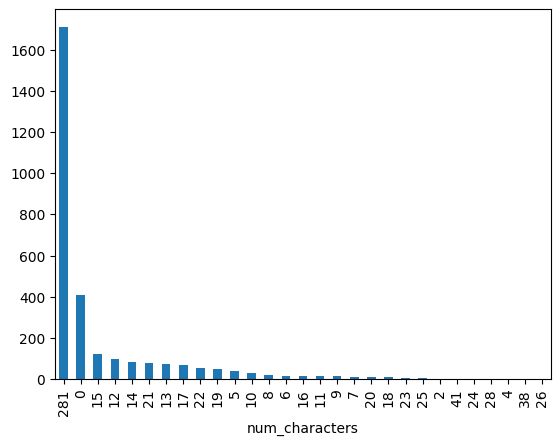

In [10]:
df['num_characters'].value_counts().sort_values(ascending=False).plot.bar();

The sampling rate is the same for each file

In [11]:
np.unique(df['sampling_rate'])

array([22050])

Etnicity is not balanced and is not well distributed

In [12]:
df['ethnicity'].value_counts().sort_values(ascending=False).to_dict()

{'igbo': 1081,
 'english': 579,
 'arabic': 102,
 'mandarin': 65,
 'french': 63,
 'korean': 52,
 'portuguese': 48,
 'russian': 48,
 'dutch': 47,
 'german': 36,
 'polish': 34,
 'italian': 33,
 'urhobo': 32,
 'japanese': 27,
 'ibibio': 27,
 'macedonian': 26,
 'farsi': 23,
 'cantonese': 23,
 'igala': 22,
 'amharic': 20,
 'romanian': 20,
 'bulgarian': 18,
 'hindi': 18,
 'bengali': 17,
 'greek': 15,
 'congolese': 13,
 'nepali': 13,
 'yoruba': 12,
 'hausa': 11,
 'miskito': 11,
 'kurdish': 10,
 'ika': 10,
 'obudu': 10,
 'pashto': 10,
 'punjabi': 10,
 'hungarian': 9,
 'hebrew': 9,
 'albanian': 9,
 'gujarati': 9,
 'czech': 9,
 'kiswahili': 9,
 'mongolian': 9,
 'bosnian': 9,
 'danish': 8,
 'indonesian': 8,
 'armenian': 8,
 'croatian': 8,
 'finnish': 8,
 'khmer': 7,
 'lithuanian': 6,
 'krio': 6,
 'ga': 6,
 'norwegian': 6,
 'nigerian': 5,
 'malay': 5,
 'georgian': 5,
 'bambara': 5,
 'dari': 5,
 'estonian': 4,
 'tiv': 4,
 'kikuyu': 4,
 'malayalam': 4,
 'catalan': 4,
 'latvian': 3,
 'lao': 3,
 'icela

Tempo should be preprocessed and converted to float

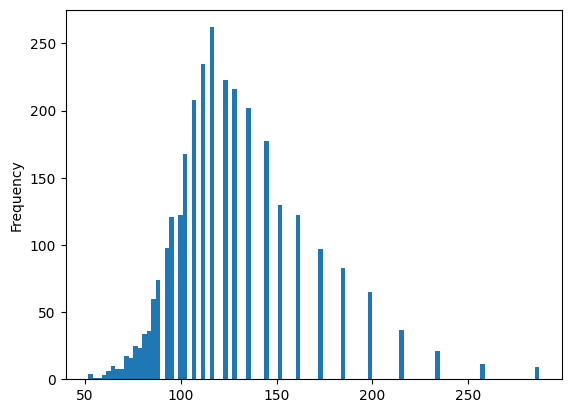

In [13]:
df['tempo'], df['tempo'].map(lambda x:x[1:-1]).astype(np.float32).plot.hist(bins=100);

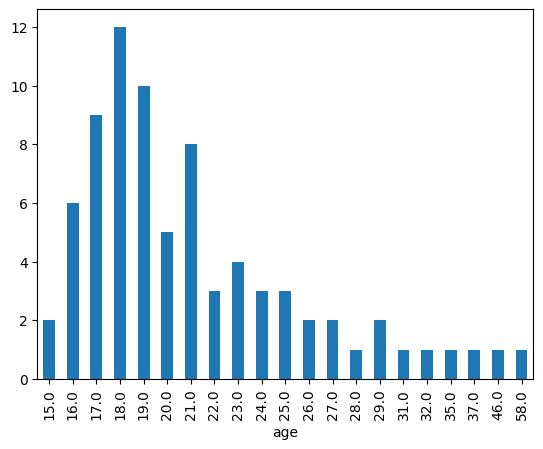

In [14]:
df[df['tempo'].map(lambda x:x[1:-1]).astype(np.float32)>200]['age'].value_counts().sort_index().plot.bar();

silence duration has outlier, could probably cut after 35

In [15]:
df['silence_duration'].map(lambda x:round(x)).value_counts().sort_index()

silence_duration
1     527
2     577
3     102
4      11
5       6
13      1
14      7
15     38
16     88
17    130
18    185
19    175
20    189
21    174
22    145
23    108
24     81
25     82
26     64
27     54
28     30
29     25
30     22
31     23
32     16
33     12
34     11
35     12
36      4
37      2
38      4
39      5
40      2
41      4
42      2
43      1
44      2
46      2
48      3
50      2
51      1
57      1
65      1
75      1
84      1
Name: count, dtype: int64

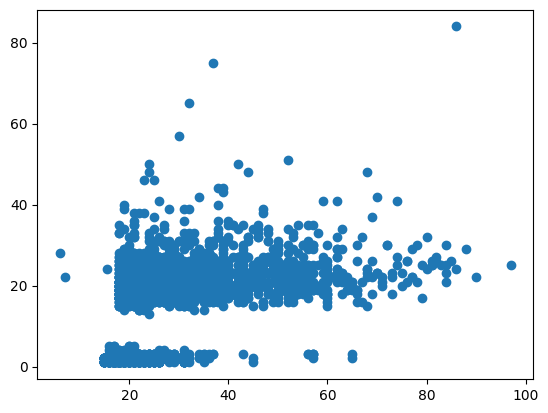

In [16]:
import matplotlib.pyplot as plt

plt.plot(df['age'], df['silence_duration'].map(lambda x:round(x)), 'o')

num pauses has many outlier

In [17]:
df['num_pauses'].map(round).value_counts().sort_index(ascending=False)

num_pauses
97       1
84       1
83       1
81       1
78       1
      ... 
5       11
4       30
3       43
2      113
1     1222
Name: count, Length: 75, dtype: int64

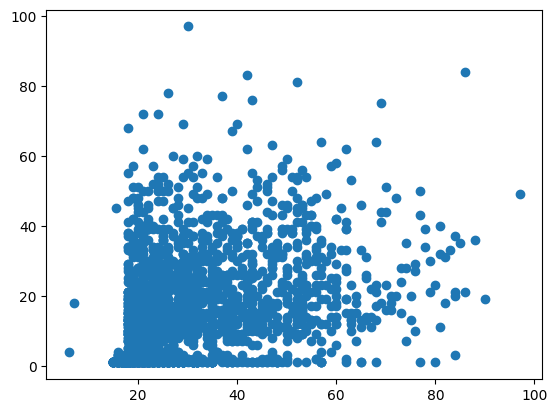

In [18]:
plt.plot(df['age'], df['num_pauses'].map(round), 'o')

hnr has outliers

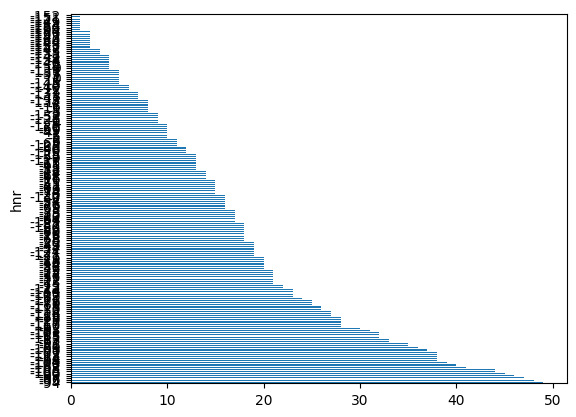

In [19]:
df['hnr'].map(round).value_counts().plot.barh();

<Axes: >

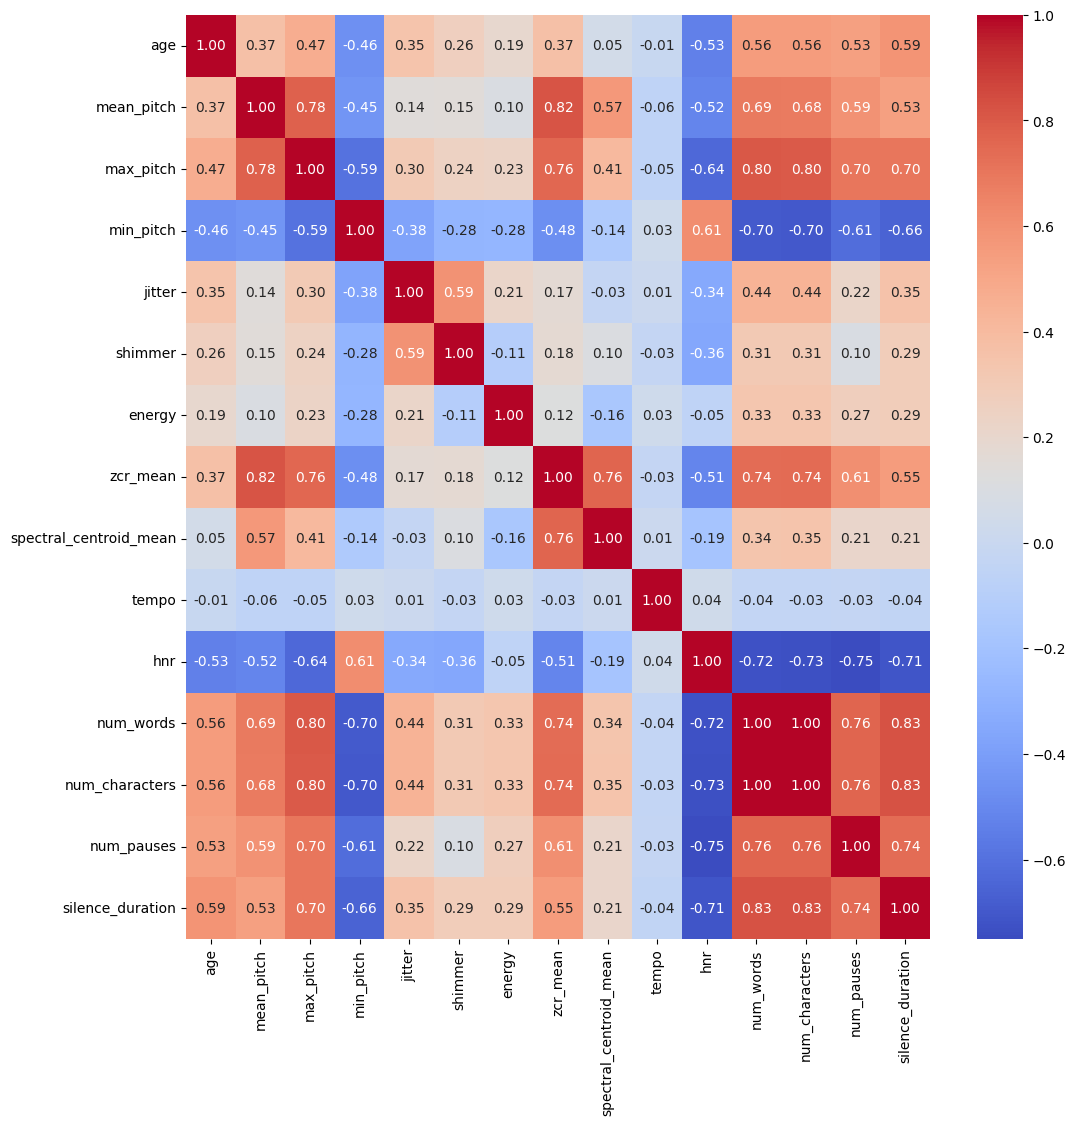

In [20]:
import seaborn as sns
temp = df.copy().drop('sampling_rate', axis=1)
temp['tempo'] = temp['tempo'].map(lambda x:x[1:-1]).astype(np.float32)

plt.figure(figsize=(12, 12))
sns.heatmap(temp.corr(method='spearman', numeric_only=True), annot=True, fmt=".2f", cmap='coolwarm')

In [21]:
import seaborn as sns
temp = df.copy().drop('sampling_rate', axis=1)
temp['tempo'] = temp['tempo'].map(lambda x:x[1:-1]).astype(np.float32)
temp['gender'] = temp['gender'].map(lambda x:0 if x == 'male' else 1)

<Axes: >

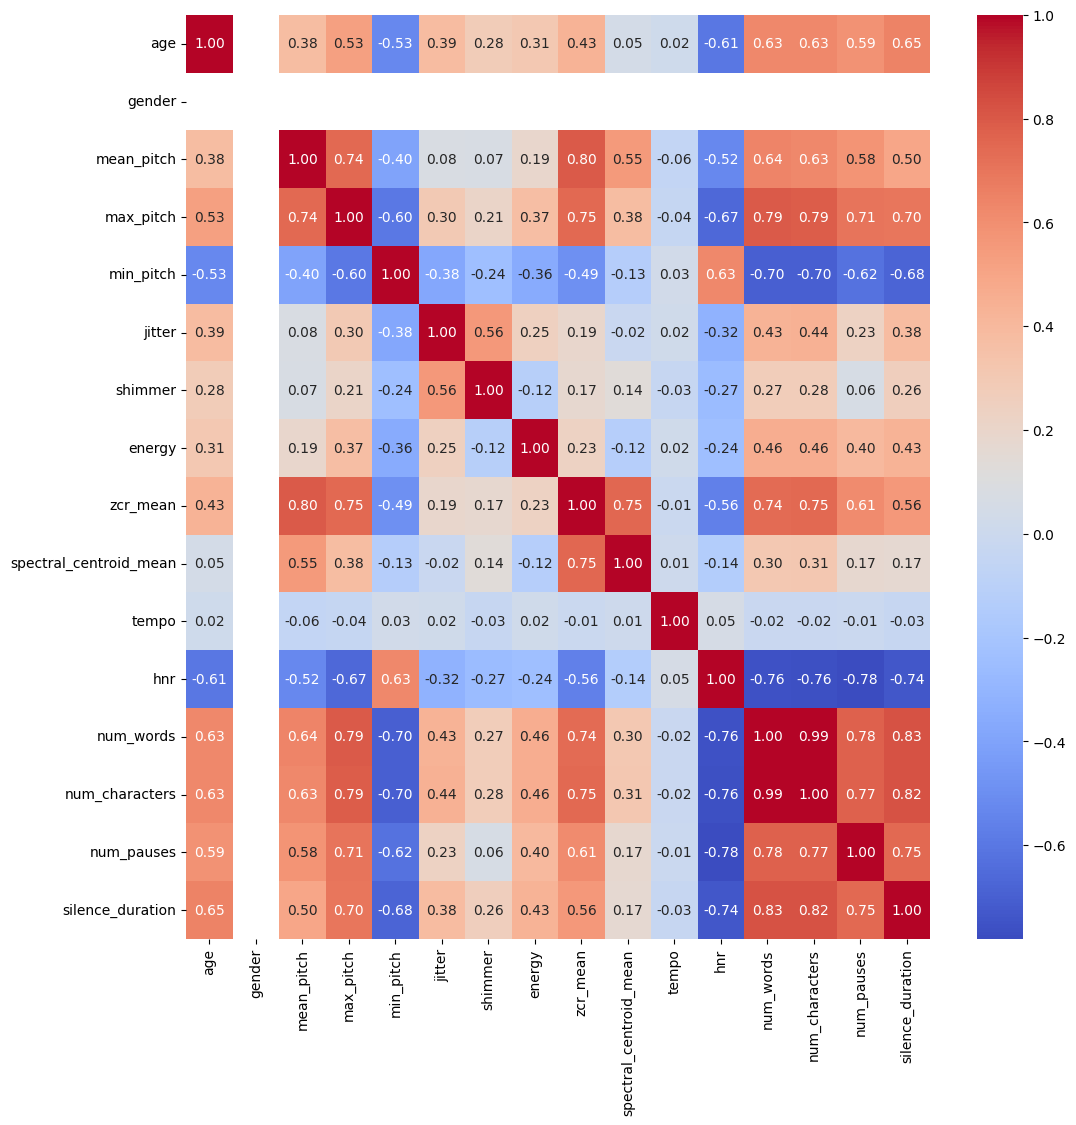

In [22]:
# Male
plt.figure(figsize=(12, 12))
sns.heatmap(temp[temp['gender']==1].corr(method='spearman', numeric_only=True), annot=True, fmt=".2f", cmap='coolwarm')

<Axes: >

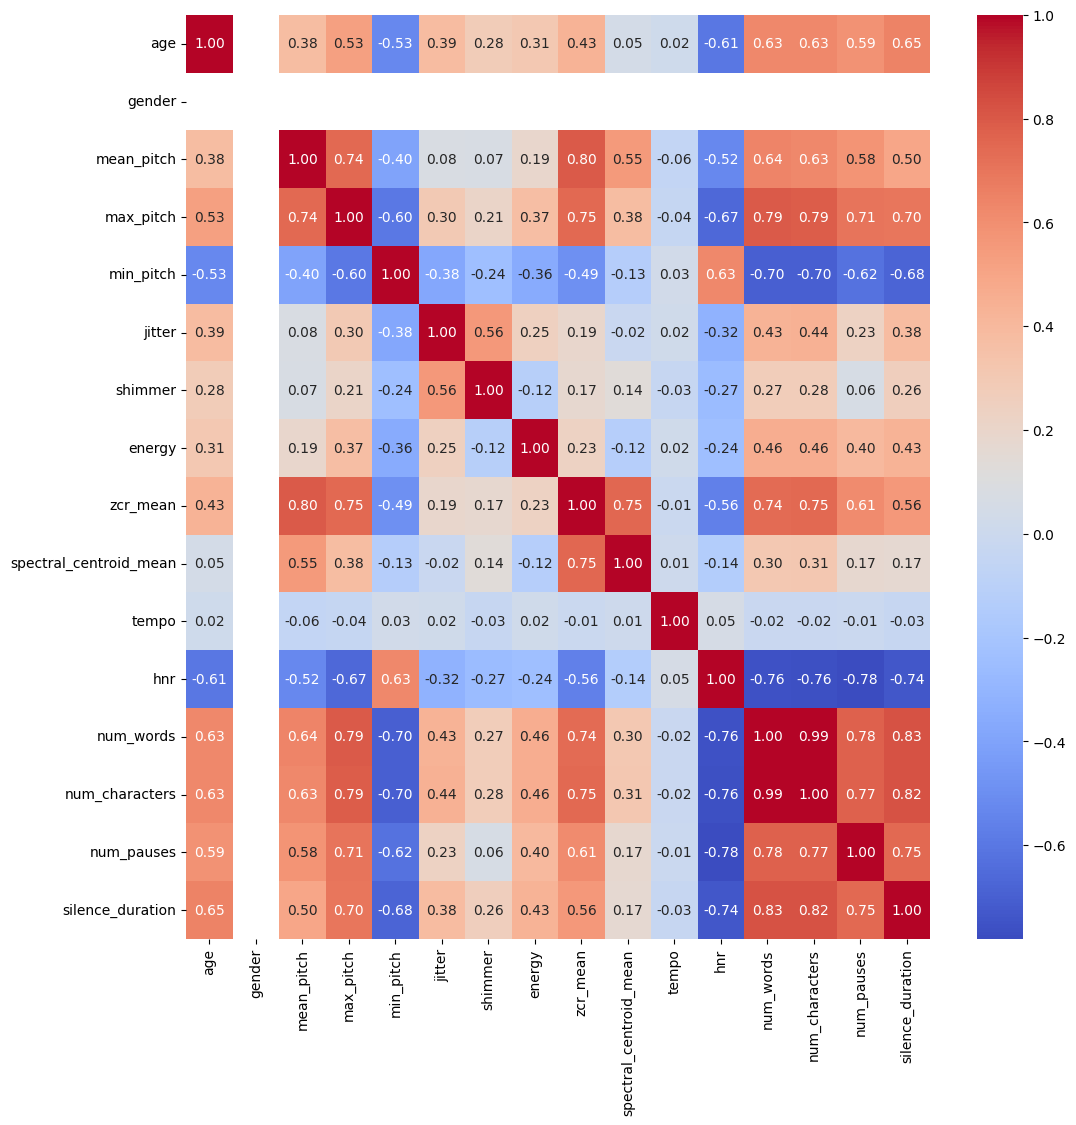

In [23]:
# female
plt.figure(figsize=(12, 12))
sns.heatmap(temp[temp['gender']==1].corr(method='spearman', numeric_only=True), annot=True, fmt=".2f", cmap='coolwarm')

In [24]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import root_mean_squared_error
import pandas as pd
import numpy as np


setting = [[col, 0] for col in temp.columns]
setting[0][1] = 1
setting[1][1] = 0
setting[2][1] = 1

In [25]:
setting

[['age', 1],
 ['gender', 0],
 ['ethnicity', 1],
 ['mean_pitch', 0],
 ['max_pitch', 0],
 ['min_pitch', 0],
 ['jitter', 0],
 ['shimmer', 0],
 ['energy', 0],
 ['zcr_mean', 0],
 ['spectral_centroid_mean', 0],
 ['tempo', 0],
 ['hnr', 0],
 ['num_words', 0],
 ['num_characters', 0],
 ['num_pauses', 0],
 ['silence_duration', 0]]

In [ ]:
def recursive_feature_elimination(df, setting, index, results):
    if index == len(setting):
        results.append([list(setting[3:]), 
                        cross_val_score(MLPRegressor(max_iter=500), 
                                        temp.drop(columns=list(map(lambda x:x[0], filter(lambda i: i[1], setting)))), 
                    temp['age'], scoring='neg_root_mean_squared_error', cv=10)])
        return
    
    setting[index][1] = 1
    recursive_feature_elimination(df, setting, index+1, results)
    setting[index][1] = 0
    recursive_feature_elimination(df, setting, index+1, results)
    
    
for res in sorted(recursive_feature_elimination(temp, setting, 3, []), key=lambda x:x[1].mean(), reverse=False):
    print(res[0], res[1].mean())

c:\Users\utente\OneDrive\Desktop\Magistrale\01TWZSM_DataScienceLab\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\utente\OneDrive\Desktop\Magistrale\01TWZSM_DataScienceLab\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\utente\OneDrive\Desktop\Magistrale\01TWZSM_DataScienceLab\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\utente\OneDrive\Desktop\Magistrale\01TWZSM_DataScienceLab\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarn